# 第 1 週:一維桿件靜力問題——四種方法交叉驗證

**課程:計算力學方法論——驗證、確效與跨平台交叉比對**

本週目標:建立全學期都會重複使用的核心框架——**同一個力學問題,用四種理論獨立或實作獨立的方法求解,並比較結果**。

四種方法:
1. **解析解**——直接對統御 ODE 積分,作為所有數值方法的基準
2. **pyFEM(手算)**——不依賴任何有限元素套件,手動實作形狀函數、高斯積分、矩陣組裝
3. **Weak Form(scikit-fem)**——用套件直譯弱形式(變分形式),驗證手算程式碼是否與成熟套件等價
4. **SciPy BVP**——完全不涉及有限元素理論,對強形式 ODE 做搭配法(collocation)求解,作為獨立驗證途徑

> 這份 notebook 可以直接在 Colab 開啟執行,不需要在本機安裝任何環境。

## 0. 環境準備

In [1]:
%pip install -q scikit-fem scipy matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
from skfem import MeshLine, ElementLineP1, Basis, BilinearForm, LinearForm, solve, condense

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


## 1. 問題描述與統御方程式

一根長度 $L$、楊氏模數 $E$、截面積 $A$ 之均質桿件,沿軸向承受單位長度均佈外力 $f$。
左端 $x=0$ 固定,右端 $x=L$ 自由。統御方程式:

$$-EA\,u''(x) = f, \quad 0<x<L$$

邊界條件:$u(0)=0$(固定端),$EA\,u'(L)=0$(自由端,力邊界條件)。

積分兩次代入邊界條件,得封閉解析解:

$$u(x) = \frac{f}{2EA}\left(2Lx - x^2\right)$$

In [2]:
# ==========================================
# 0. 問題物理參數設定 (1D 桿件受拉伸)
# ==========================================
L = 1.0       # 桿件長度 (m)
E = 100.0     # 楊氏模數 (Pa)
A = 1.0       # 截面積 (m^2)
f_val = 10.0  # 均佈外力 (N/m)
n_elements = 4 # 有限元素法使用的單元數量
n_nodes = n_elements + 1

# ------------------------------------------
# 方法一:解析解 (Exact Solution)
# ------------------------------------------
x_fine = np.linspace(0, L, 100)
u_exact = (f_val / (2 * E * A)) * (2 * L * x_fine - x_fine**2)

## 2. 方法二:pyFEM(手算有限元素法)

完全不依賴套件,自行實作:
- 二節點線性元素,自然座標 $\xi\in[-1,1]$
- 形狀函數 $N_1=(1-\xi)/2,\ N_2=(1+\xi)/2$
- 二點高斯積分($\xi=\pm1/\sqrt3$,權重均為 1)計算元素剛度矩陣與等效節點力
- 直接勁度法組裝全域矩陣,施加邊界條件後求解

In [3]:
nodes = np.linspace(0, L, n_nodes)
elements = [[i, i+1] for i in range(n_elements)]

K_pyfem = np.zeros((n_nodes, n_nodes))
F_pyfem = np.zeros(n_nodes)

# 兩點高斯積分點與權重
gauss_pts = [-1.0 / np.sqrt(3), 1.0 / np.sqrt(3)]
gauss_wts = [1.0, 1.0]

for elem in elements:
    n1, n2 = elem
    x1, x2 = nodes[n1], nodes[n2]
    he = x2 - x1
    J = he / 2.0

    Ke = np.zeros((2, 2))
    Fe = np.zeros(2)

    for xi, w in zip(gauss_pts, gauss_wts):
        dNdxi = np.array([-0.5, 0.5])
        B = dNdxi / J
        N = np.array([0.5 * (1 - xi), 0.5 * (1 + xi)])

        Ke += np.outer(B, B) * (E * A) * J * w
        Fe += N * f_val * J * w

    for i in range(2):
        F_pyfem[elem[i]] += Fe[i]
        for j in range(2):
            K_pyfem[elem[i], elem[j]] += Ke[i, j]

# 邊界條件 u(0) = 0
K_bc = K_pyfem.copy()
F_bc = F_pyfem.copy()
K_bc[0, :] = 0.0
K_bc[:, 0] = 0.0
K_bc[0, 0] = 1.0
F_bc[0] = 0.0

u_pyfem = np.linalg.solve(K_bc, F_bc)
print("u_pyfem =", np.round(u_pyfem, 6))

u_pyfem = [0.       0.021875 0.0375   0.046875 0.05    ]


## 3. 方法三:Weak Form(scikit-fem)

與方法二理論基礎完全相同(加勒金法弱形式),但改用套件直譯數學式,而非手動組裝矩陣:

$$\int_0^L EA\,u'v'\,dx = \int_0^L f v\,dx,\quad \forall v,\ v(0)=0$$

**這一步的目的**:如果結果與方法二一致,即可交叉驗證手算矩陣組裝與邊界條件處理邏輯的正確性。

In [4]:
mesh = MeshLine(np.linspace(0, L, n_nodes))
element = ElementLineP1()
basis = Basis(mesh, element)

@BilinearForm
def a_form(u, v, w):
    return E * A * u.grad[0] * v.grad[0]

@LinearForm
def L_form(v, w):
    return f_val * v

A_mat = a_form.assemble(basis)
b_vec = L_form.assemble(basis)

all_bnd = mesh.boundary_nodes()
D = all_bnd[mesh.p[0, all_bnd] == 0.0]

u_weak = solve(*condense(A_mat, b_vec, D=D))
print("u_weak =", np.round(u_weak, 6))

u_weak = [0.       0.021875 0.0375   0.046875 0.05    ]


## 4. 方法四:SciPy BVP(獨立驗證途徑)

完全不涉及有限元素或變分理論,直接對強形式 ODE 數值求解。降階為一階系統:

$$y_1' = y_2,\qquad y_2' = -\frac{f}{EA}$$

邊界條件:$y_1(0)=0,\ y_2(L)=0$。`solve_bvp` 採用隱式搭配法(collocation),
理論基礎與有限元素法的加勒金投影完全獨立——若結果仍與前兩者一致,構成有力的三角驗證。

In [5]:
def ode_system(x, y):
    return np.vstack((y[1], -np.full_like(x, f_val / (E * A))))

def boundary_conditions(ya, yb):
    return np.array([ya[0], yb[1]])

x_bvp_mesh = np.linspace(0, L, 5)
y_guess = np.zeros((2, x_bvp_mesh.size))

sol_bvp = solve_bvp(ode_system, boundary_conditions, x_bvp_mesh, y_guess)
u_scipy = sol_bvp.sol(nodes)[0]
print("u_scipy =", np.round(u_scipy, 6))

u_scipy = [-0.        0.021875  0.0375    0.046875  0.05    ]


## 5. 結果比較

In [6]:
u_exact_nodes = (f_val / (2 * E * A)) * (2 * L * nodes - nodes**2)

print("=== 各種算法在節點上的位移結果 (m) ===")
print(f"Exact Solution : {np.round(u_exact_nodes, 8)}")
print(f"pyFEM Logic    : {np.round(u_pyfem, 8)}")
print(f"Weak Form      : {np.round(u_weak, 8)}")
print(f"SciPy BVP      : {np.round(u_scipy, 8)}")

err_pyfem = np.abs(u_pyfem - u_exact_nodes)
err_weak  = np.abs(u_weak  - u_exact_nodes)
err_scipy = np.abs(u_scipy - u_exact_nodes)

print("\n=== 節點絕對誤差 (m) ===")
print(f"pyFEM vs Exact : max = {err_pyfem.max():.3e}")
print(f"Weak  vs Exact : max = {err_weak.max():.3e}")
print(f"SciPy vs Exact : max = {err_scipy.max():.3e}")
print(f"pyFEM vs Weak  : max = {np.max(np.abs(u_pyfem - u_weak)):.3e}")

=== 各種算法在節點上的位移結果 (m) ===
Exact Solution : [0.       0.021875 0.0375   0.046875 0.05    ]
pyFEM Logic    : [0.       0.021875 0.0375   0.046875 0.05    ]
Weak Form      : [0.       0.021875 0.0375   0.046875 0.05    ]
SciPy BVP      : [-0.        0.021875  0.0375    0.046875  0.05    ]

=== 節點絕對誤差 (m) ===
pyFEM vs Exact : max = 3.469e-17
Weak  vs Exact : max = 6.939e-18
SciPy vs Exact : max = 6.939e-18
pyFEM vs Weak  : max = 3.469e-17


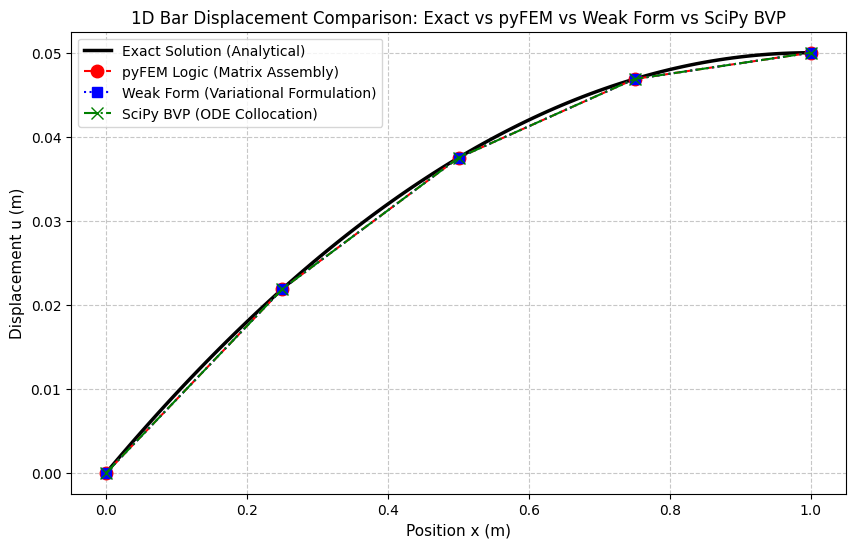

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(x_fine, u_exact, 'k-', label='Exact Solution (Analytical)', linewidth=2.5)
plt.plot(nodes, u_pyfem, 'ro--', label='pyFEM Logic (Matrix Assembly)', markersize=9)
plt.plot(nodes, u_weak, 'bs:', label='Weak Form (Variational Formulation)', markersize=7)
plt.plot(nodes, u_scipy, 'gx-.', label='SciPy BVP (ODE Collocation)', markersize=8)
plt.title("1D Bar Displacement Comparison: Exact vs pyFEM vs Weak Form vs SciPy BVP", fontsize=12)
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Displacement u (m)", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 6. 討論題(課堂/作業)

1. 表格中四種方法的節點誤差都在機器精度量級(約 $10^{-16}\sim10^{-18}$),而不是「數值上足夠接近」。
   查資料或用手推導,說明為什麼**線性有限元素解在等係數一維桿件問題中,節點值會與解析解完全相等**
   (提示關鍵字:nodal exactness / superconvergence)。
2. 如果把 `f_val` 換成 $f(x)=\sin(\pi x/L)$ 這種非常數分布荷重,你預期第 1 題的節點精確性還會成立嗎?
   實際改程式跑一次驗證你的預期。
3. `n_elements` 從 4 改成 1,pyFEM 與 Weak Form 還會一致嗎?解析解呢?這說明了「兩個實作互相驗證一致」
   跟「兩個實作都對」是不是同一件事?
4. 把 SciPy BVP 的初始網格 `x_bvp_mesh` 從 5 個點改成 2 個點(只有頭尾),`solve_bvp` 還能收斂到同樣精度嗎?
   這跟第 11 週要教的「收斂陷阱」有什麼關係?

## 下週預告

第 2 週會把本週「已知答案、驗證用途」的桿件問題,倒過來重新走一次:
從統御方程式出發,正式推導強形式與弱形式的等價性,並開始建立本課程貫穿全學期的
「四方比對」框架的理論基礎。